In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDK174"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47

# symmetrical shape

In [21]:
name_dict = dict(
    data1 = dict(amp=0.2, date="2025-02-20", acquire_time="115134", params=dict(fit_start=250, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.3, date="2025-02-20", acquire_time="121305", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)),
    data25 = dict(amp=0.35, date="2025-02-20", acquire_time="122035", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data3 = dict(amp=0.4, date="2025-02-20", acquire_time="123118", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data35 = dict(amp=0.425, date="2025-02-20", acquire_time="124210", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data4
    # data4 = dict(amp=0.5, date="2025-02-18", acquire_time="155452", params=dict(fit_start=140, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
)

# Generating Control Pulses

0.2 2025-02-20 115134
0.3 2025-02-20 121305
0.35 2025-02-20 122035
0.4 2025-02-20 123118
0.425 2025-02-20 124210


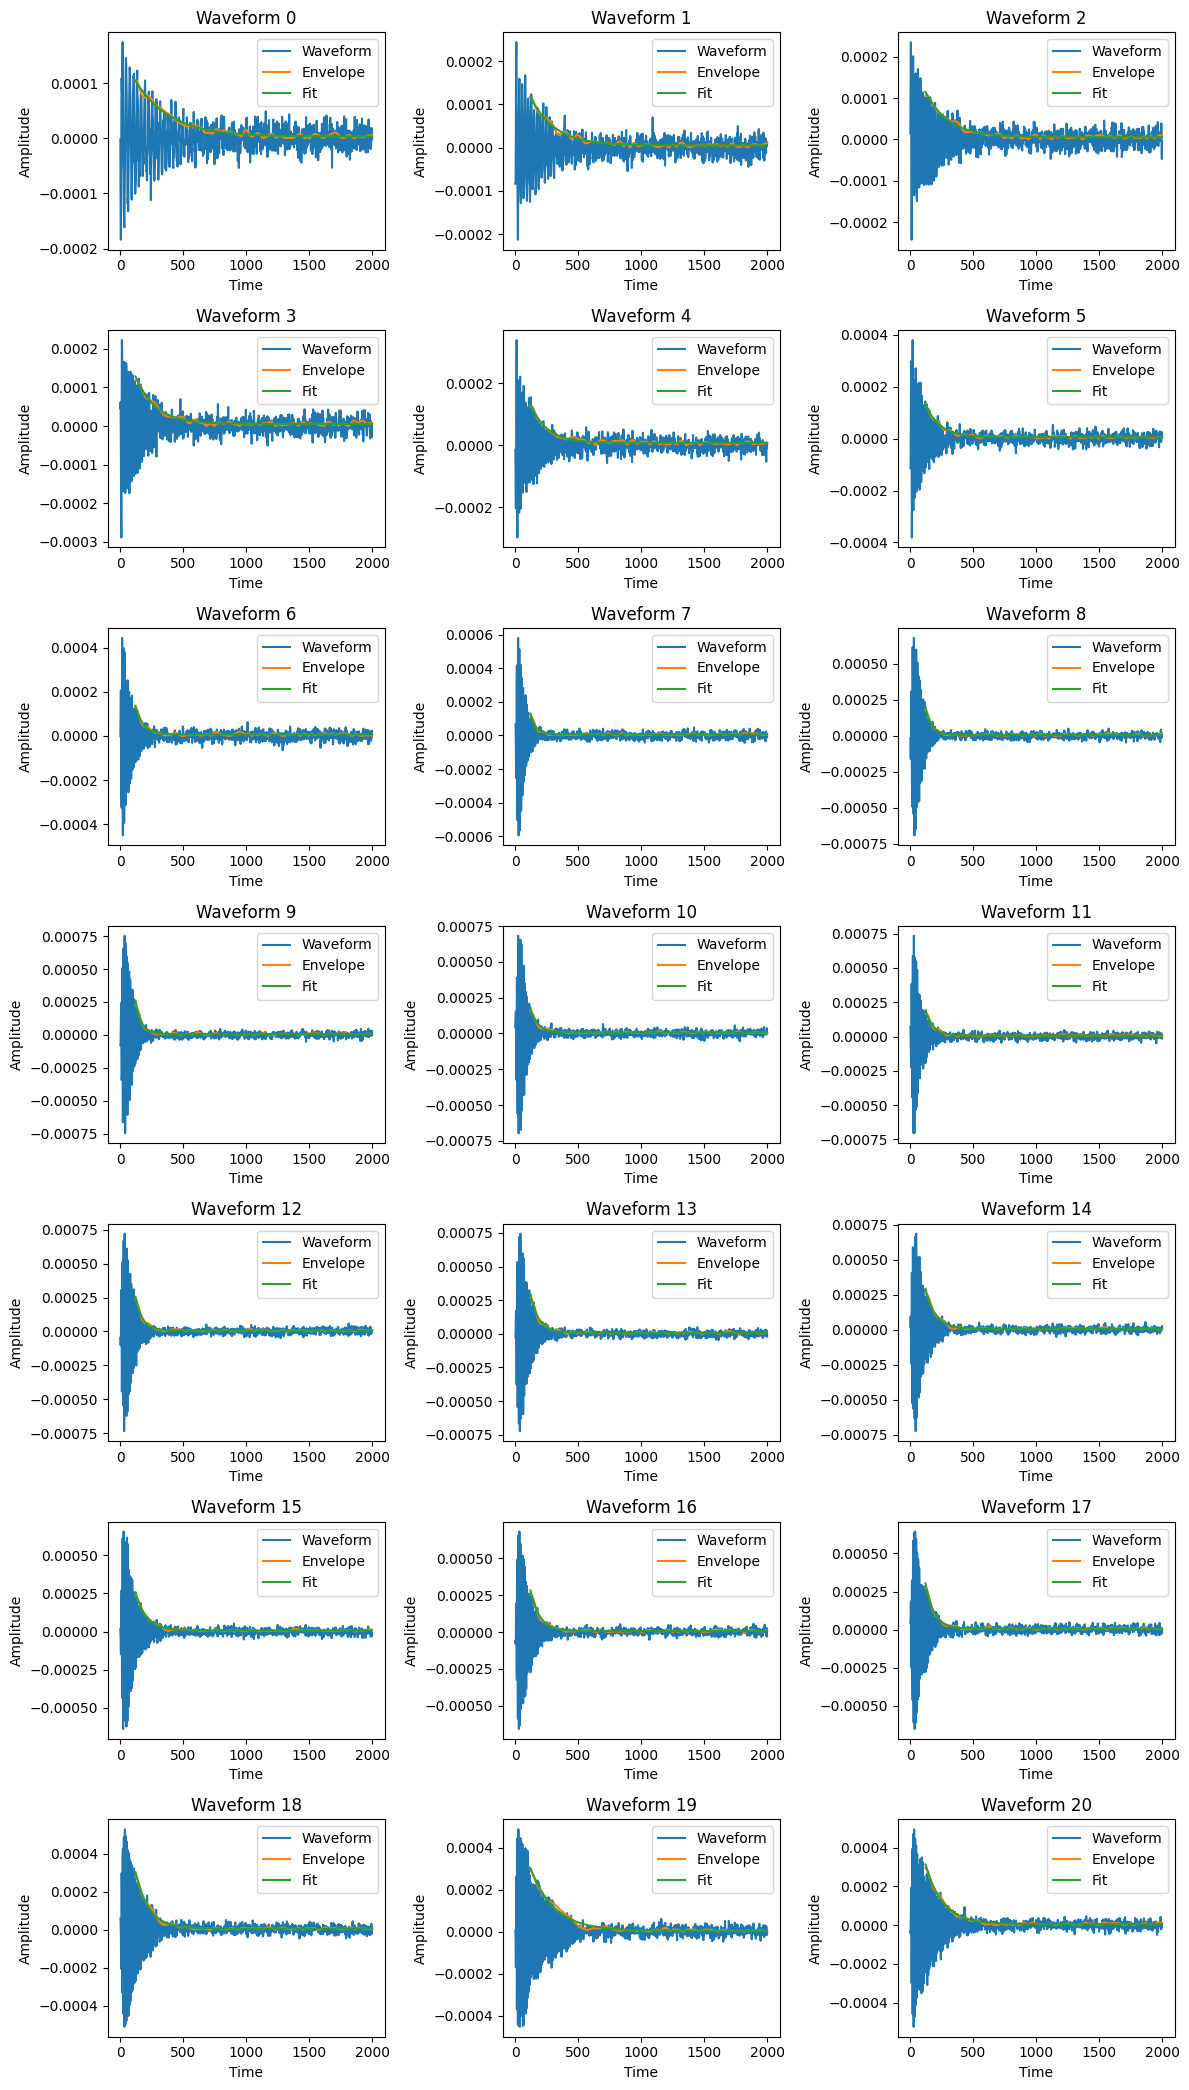

In [22]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

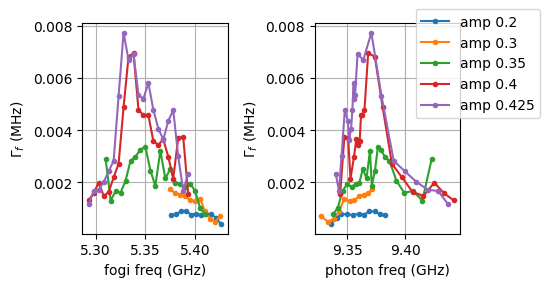

{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}
[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.999992

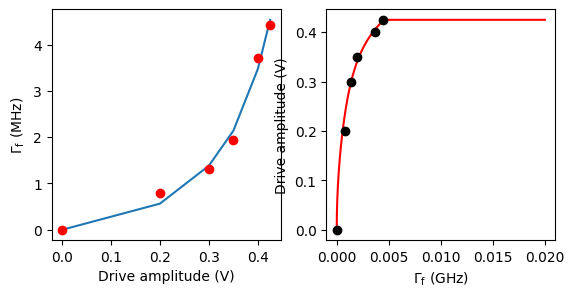

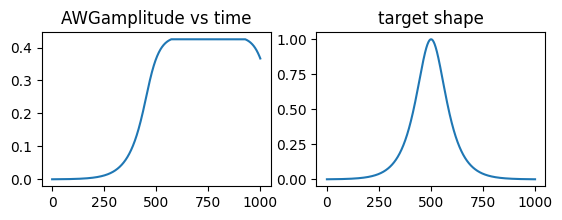

[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.99999291e-01
 9.99999264e-01 9.99999236e-01 9.99999206e-01 9.99999176e-01
 9.99999145e-01 9.99999113e-01 9.99999079e-01 9.99999045e-01
 9.99999010e-01 9.999989

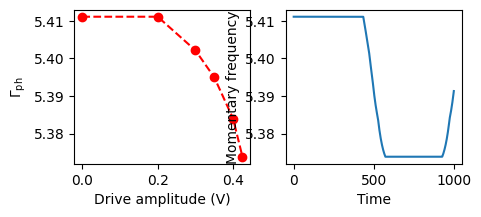

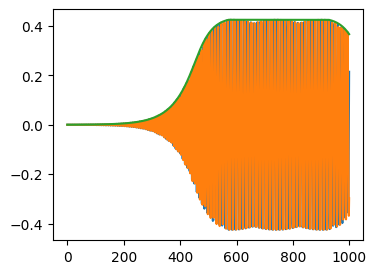

In [23]:
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.29, target_freq, duration, const=const, form="sech_0", tr=False)[0]

## save

In [24]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
forms = ["sech_0", "sech_1", "sech_2", "sech_3"] 

for form in forms:
    for target_freq in [9.35]:
        control_pulse, control_envelope = dataobj.generate_control_pulse(
            5.29, target_freq, duration, const=const, form=form, plot=False, tr=False
        )

        note = f"""
        form : {form}
        const : {const / 2 / np.pi}
        duration : {duration}
        target frequency : {target_freq} GHz
        """

        data = DataDict(
            time=dict(unit="ns"),
            control_pulse=dict(axes=["time"]),
            control_envelope=dict(axes=["time"])
        )
        data.validate()

        save_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

        with DDH5Writer(data, save_path, name="Control_Pulse") as writer:
            writer.add_tag(["control_pulse", cd, form])
            writer.save_text("target_shape.md", note)
            writer.add_data(
                time=np.arange(len(control_pulse)),
                control_pulse=control_pulse,
                control_envelope=control_envelope
            )
        T.sleep(1)


{'a0': 0, 'a2': 0.014006731189855737, 'a4': 1.5543122344752192e-13, 'a6': 2.2238295649401607e-08, 'a8': 1.882229010061982, 'a10': 1.026090545863667e-09}
[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.999992

# Photon shaping analysis

In [2]:
from Analysis import SechPhotonAnalysis
import numpy as np
import matplotlib.pyplot as plt
cd = "CDK174"

Form: sech_0, Symmetry: 0.5455877452853546, Overlap: 0.9930061323723021
Form: sech_1, Symmetry: 0.12219980911815212, Overlap: 0.9880835365980756
Form: sech_2, Symmetry: 0.2058574730776309, Overlap: 0.9778384565040475
Form: sech_3, Symmetry: 0.1726809277875398, Overlap: 0.9689263003485501


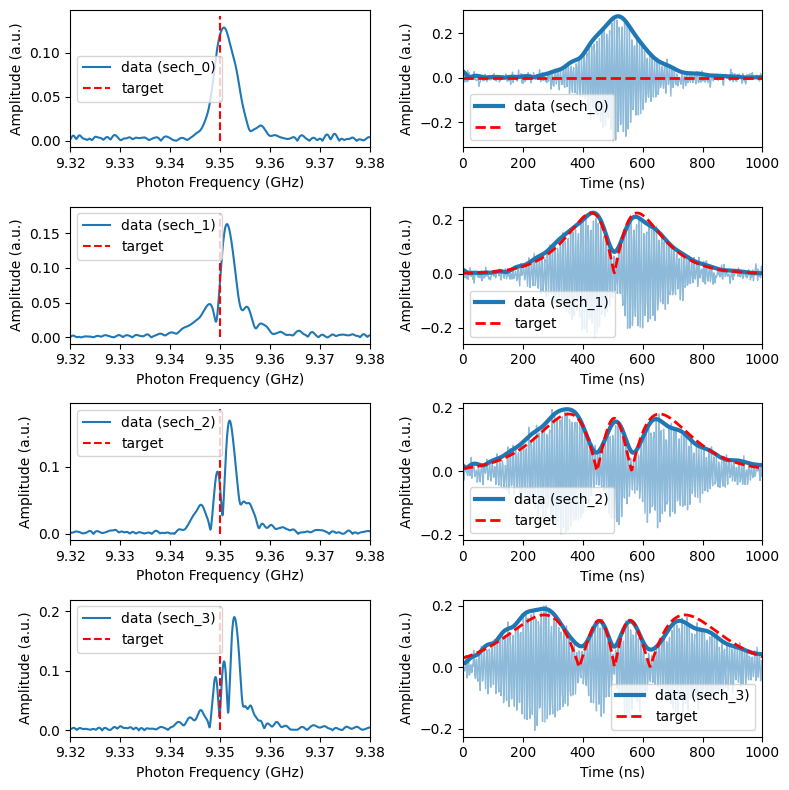

In [3]:
data_path = f"D:\\K_Sunada\\result\\{cd}"
readout_lo_freq = 9.47
duration = 1000
passing_band = 0.01
const = 2.5e-3*2*np.pi
result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="102937", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="103014", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="103050", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="103127", form="sech_3"),
}

analyzer = SechPhotonAnalysis(data_path, result_dict, duration, const, readout_lo_freq)
analyzer.analyze_waveforms(passing_band)

phase subtraction

In [4]:
ctrl_pulse_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\"
# analyzer.phase_subtraction_and_pulse_flip(ctrl_pulse_path)

corrected photon shaping

Form: sech_0, Symmetry: 0.9782520176832245, Overlap: 0.9947987046709694
Form: sech_1, Symmetry: 0.9303909551427757, Overlap: 0.9916892841559959
Form: sech_2, Symmetry: 0.9002953450362546, Overlap: 0.9876555089895067
Form: sech_3, Symmetry: 0.8323495620693577, Overlap: 0.9696410391538908


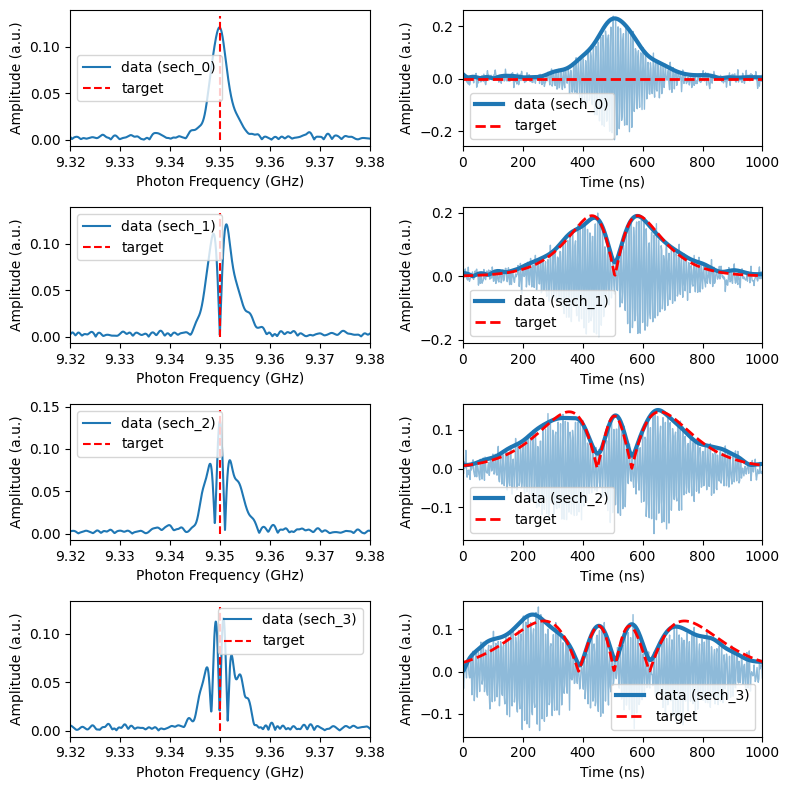

In [5]:
const = 2.5e-3*2*np.pi
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="103408", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="103446", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="103522", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="103559", form="sech_3"),
}

corrected_analyzer = SechPhotonAnalysis(data_path, corrected_result_dict, duration, const, readout_lo_freq)
corrected_analyzer.analyze_waveforms(passing_band)

fogi pulse generation for absoption

Saved Recieve_Pulse for data_sech_0 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_1 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_2 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_3 at D:\K_Sunada\result\control_pulses\CDK174\


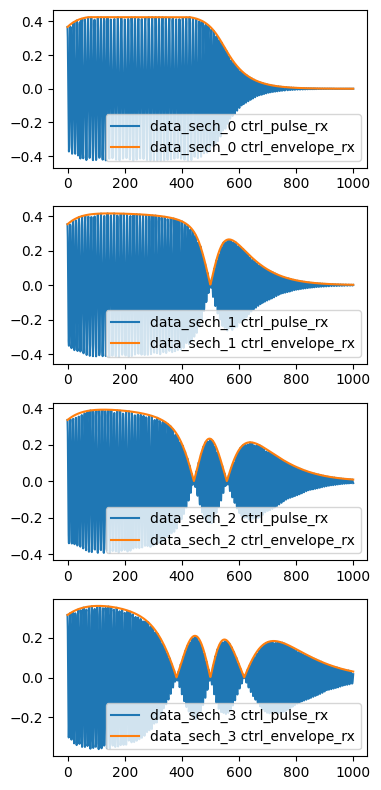

In [6]:
corrected_analyzer.generate_control_pulse_rx(ctrl_pulse_path)

In [45]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from plottr.data.datadict_storage import DataDict, DDH5Writer

date = "2025-02-20"
acquire_time="131401"
# result_dict = dict(
#     data = dict(target_freq=9.35, date="2025-02-18", acquire_time="112802", form="sech_1"),
# )

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
# for i in range(int(len(env_rvs)/2), len(env_rvs)):
#     env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

In [41]:
date = "2025-02-20"
acquire_time="172953"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in range(442, 557):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

  0%|          | 0/4 [00:00<?, ?it/s]d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
 25%|██▌       | 1/4 [00:00<00:02,  1.07it/s]

[ 3.90931577e-01+0.00000000e+00j  3.23934228e-01+2.22270991e-01j
  1.43045590e-01+3.67910629e-01j -8.85058579e-02+3.86576893e-01j
 -2.90808884e-01+2.72272202e-01j -3.94897965e-01+6.44739425e-02j
 -3.65903365e-01-1.66095851e-01j -2.14819312e-01-3.41570209e-01j
  6.99714560e-03-4.05075109e-01j  2.26787181e-01-3.37628001e-01j
  3.74525178e-01-1.62540849e-01j  4.04802727e-01+6.37216829e-02j
  3.09845232e-01+2.70430177e-01j  1.20312835e-01+3.94773727e-01j
 -1.05508256e-01+4.00435748e-01j -3.00124451e-01+2.87297923e-01j
 -4.06962535e-01+9.00294588e-02j -3.96283319e-01-1.33295615e-01j
 -2.72622650e-01-3.18661523e-01j -7.22102970e-02-4.14355029e-01j
  1.48285683e-01-3.94877608e-01j  3.28066853e-01-2.66980212e-01j
  4.18841754e-01-6.66659002e-02j  3.97111692e-01+1.51417648e-01j
  2.69485979e-01+3.28637044e-01j  7.07009933e-02+4.19077999e-01j
 -1.46752984e-01+3.98859075e-01j -3.25456018e-01+2.73319191e-01j
 -4.18220579e-01+7.56078524e-02j -4.00551667e-01-1.42068161e-01j
 -2.77114857e-01-3.222302

 50%|█████     | 2/4 [00:01<00:01,  1.44it/s]

[ 3.74688826e-01+0.00000000e+00j  3.05336778e-01+2.20197315e-01j
  1.20314291e-01+3.58534840e-01j -1.10804506e-01+3.63359312e-01j
 -3.01996359e-01+2.33173950e-01j -3.82817671e-01+1.63125118e-02j
 -3.23930728e-01-2.07622698e-01j -1.47064112e-01-3.57228938e-01j
  8.36900596e-02-3.78705220e-01j  2.85542540e-01-2.64665249e-01j
  3.86763513e-01-5.60009015e-02j  3.51841401e-01+1.73346509e-01j
  1.93362167e-01+3.42857409e-01j -3.31359722e-02+3.93599385e-01j
 -2.49059166e-01+3.08295401e-01j -3.80147458e-01+1.16629109e-01j
 -3.81793960e-01-1.15610310e-01j -2.53758499e-01-3.09414150e-01j
 -3.96853819e-02-3.99417140e-01j  1.87854119e-01-3.56060191e-01j
  3.53523466e-01-1.95010253e-01j  4.03774408e-01+2.99139614e-02j
  3.23484232e-01+2.45333519e-01j  1.39616202e-01+3.82388904e-01j
 -8.85899837e-02+3.98410325e-01j -2.89147928e-01+2.89515689e-01j
 -4.00039669e-01+9.06814185e-02j -3.87989936e-01-1.36125010e-01j
 -2.57782394e-01-3.21571759e-01j -4.97587993e-02-4.10074407e-01j
  1.73205958e-01-3.760273

 75%|███████▌  | 3/4 [00:02<00:00,  1.57it/s]

[ 3.54923260e-01+0.00000000e+00j  2.83075898e-01+2.16662452e-01j
  9.42756479e-02+3.45365440e-01j -1.34133653e-01+3.33542025e-01j
 -3.09286413e-01+1.86137344e-01j -3.60515423e-01-3.71870985e-02j
 -2.67403546e-01-2.46747802e-01j -6.72393241e-02-3.59010575e-01j
  1.60539908e-01-3.29610128e-01j  3.26199082e-01-1.70298974e-01j
  3.64971278e-01+5.63973454e-02j  2.61934523e-01+2.62178352e-01j
  5.71380114e-02+3.67464625e-01j -1.70508137e-01+3.31896227e-01j
 -3.33906564e-01+1.69271861e-01j -3.71001749e-01-5.83779469e-02j
 -2.67942703e-01-2.64850960e-01j -6.37047748e-02-3.72498871e-01j
  1.65132733e-01-3.41181259e-01j  3.33341783e-01-1.82761932e-01j
  3.78711683e-01+4.38955091e-02j  2.84706454e-01+2.55162374e-01j
  8.60065856e-02+3.73591160e-01j -1.44721377e-01+3.56105069e-01j
 -3.23633825e-01+2.09259822e-01j -3.86136070e-01-1.36677077e-02j
 -3.09914628e-01-2.32349232e-01j -1.22481128e-01-3.68460479e-01j
  1.09156151e-01-3.73587273e-01j  3.02685332e-01-2.46106181e-01j
  3.89741539e-01-3.128657

100%|██████████| 4/4 [00:02<00:00,  1.57it/s]

[ 3.30113445e-01+0.00000000e+00j  2.58033541e-01+2.07901529e-01j
  7.11192945e-02+3.24911867e-01j -1.48347712e-01+2.99051239e-01j
 -3.03767045e-01+1.41311081e-01j -3.26704827e-01-7.93923219e-02j
 -2.06765073e-01-2.66598188e-01j  4.07222554e-03-3.38508707e-01j
  2.14290401e-01-2.63540711e-01j  3.32685025e-01-7.38580881e-02j
  3.07823017e-01+1.48762899e-01j  1.50094481e-01+3.08380995e-01j
 -7.29672161e-02+3.36207359e-01j -2.65846228e-01+2.20018977e-01j
 -3.45993430e-01+9.19591067e-03j -2.78994020e-01-2.06548376e-01j
 -9.30466022e-02-3.35464562e-01j  1.33207526e-01-3.22698734e-01j
  3.04125824e-01-1.73381270e-01j  3.47486175e-01+4.97197934e-02j
  2.44955045e-01+2.52727274e-01j  3.95206192e-02+3.50653291e-01j
 -1.83099235e-01+3.02704541e-01j -3.30416401e-01+1.28865515e-01j
 -3.41501463e-01-9.88646039e-02j -2.11850263e-01-2.86571562e-01j
  5.21212219e-03-3.57173861e-01j  2.20805610e-01-2.81836780e-01j
  3.47012319e-01-9.13593510e-02j  3.32594257e-01+1.36793252e-01j
  1.83467126e-01+3.102074

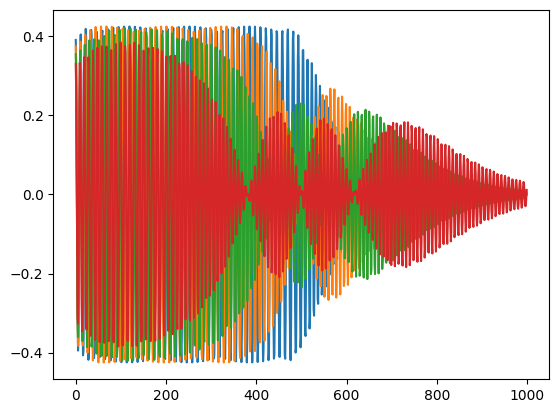

In [177]:
pulse_dict_rx = dict(
    data0 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163857"),
    data1 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163858"),
    data2 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163859"),
    data3 = dict(target_freq=9.35, date="2025-02-18", acquire_time="163900"),
)

from tqdm import tqdm
for (k_rx, v_rx) in tqdm(pulse_dict_rx.items()):
    _, datadict_rx = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", 
                                                v_rx["date"], acquire_time=v_rx["acquire_time"])
    target_shape_note_rx = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", v_rx["date"],
                                f"{_}\\target_shape.md").replace("path", "before") + f"\npath : {_}"
    control_pulse_rx = datadict_rx["control_pulse"]["values"].ravel()
    plt.plot(control_pulse_rx)
    print(control_pulse_rx)

Form: sech_0, Symmetry: 0.691524767578211, Overlap: 0.8366748114205073
Form: sech_1, Symmetry: 0.5744309392678898, Overlap: 0.5659956760670228
Form: sech_2, Symmetry: 0.606928437589644, Overlap: 0.4426684135886298
Form: sech_3, Symmetry: 0.5715415743391318, Overlap: 0.4348472655631699


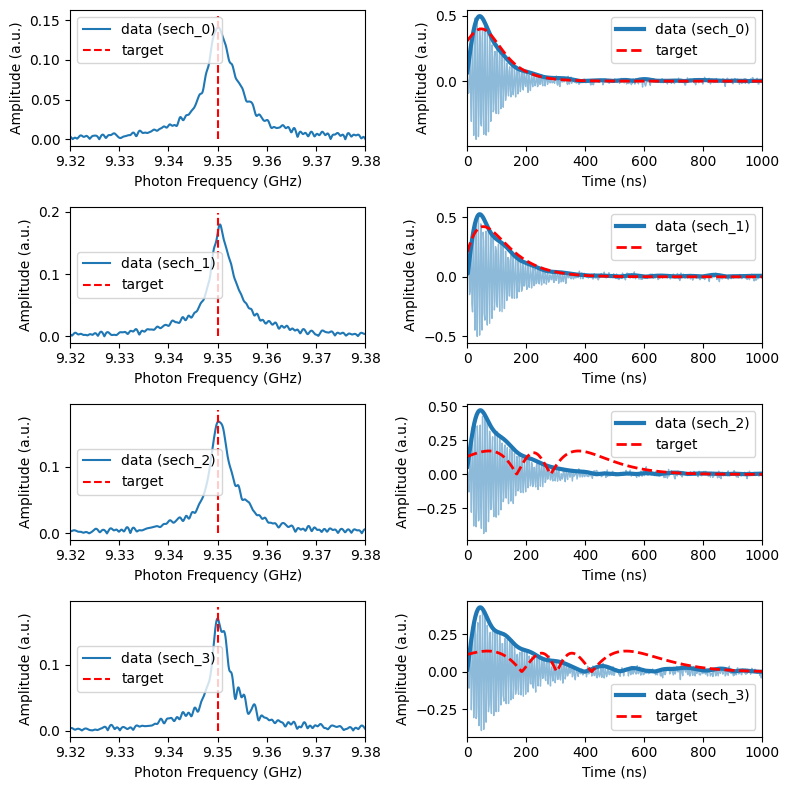

In [46]:
const = 2.5e-3*2*np.pi
reversed_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-20", acquire_time="141921", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-20", acquire_time="212628", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-20", acquire_time="142037", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-20", acquire_time="142114", form="sech_3"),
}

reversed_analyzer = SechPhotonAnalysis(data_path, reversed_result_dict, duration, const, readout_lo_freq)
reversed_analyzer.analyze_waveforms(passing_band)